<a href="https://colab.research.google.com/github/fahad15fede/Assignment-AI-ML/blob/main/Polynomial_regression_(Ice_cream_data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [ ]:
df.isna().sum()

,0
Temperature (°C),0
Ice Cream Sales (units),0


In [ ]:
print("Unique values in 'Temperature (°C)' before replacement:")
print(df['Temperature (°C)'].unique())

Unique values in 'Temperature (°C)' before replacement:
[-4.66226268 -4.31655945 -4.21398476 -3.94966109 -3.57855372 -3.4557117
 -3.10844012 -3.08130332 -2.67246083 -2.65228679 -2.65149803 -2.288264
 -2.11186969 -1.81893761 -1.66034773 -1.32637898 -1.17312327 -0.77333004
 -0.6737528  -0.14963487 -0.0361565  -0.03389529  0.0086077   0.14924457
  0.68878091  0.69359887  0.87490503  1.02418081  1.24071162  1.35981267
  1.74000001  1.85055193  1.99931037  2.0751006   2.31859124  2.471946
  2.78483646  2.83176021  2.95993209  3.02087431  3.21136614  3.27004407
  3.31607252  3.33593241  3.61077848  3.70405744  4.13086796  4.13353379
  4.89903151]


In [ ]:
df.duplicated().sum()

np.int64(0)

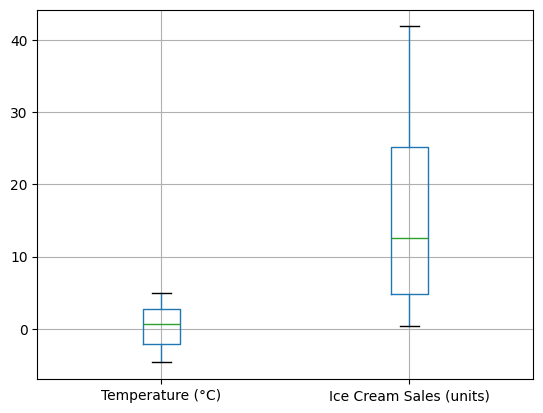

In [ ]:
df.boxplot()
plt.show()

This graph is used to show a curved path between temperature and sales

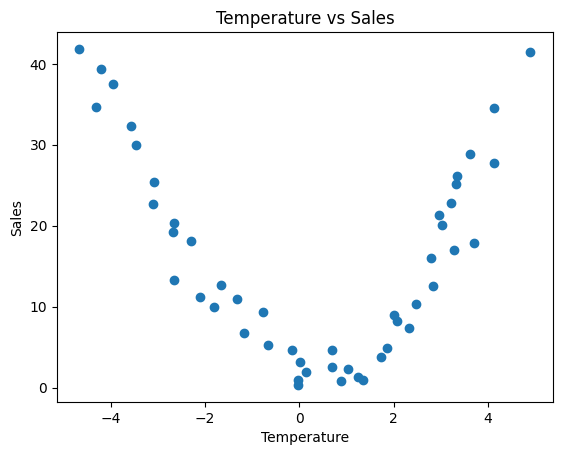

In [ ]:
plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'])
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.title("Temperature vs Sales")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score


X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])


pipe.fit(X_train, y_train)


y_pred = pipe.predict(X_test)


print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8430551371938838


In [ ]:
import pickle

# Save the pipeline
with open('ice_cream_poly_model.pkl', 'wb') as file:
    pickle.dump(pipe, file)

print("Model saved successfully!")

Model saved successfully!
